In [1]:
import sys

sys.path.append("/home/hpc/v120bb/v120bb18/UnReflectAnything")
import torch

print(torch.cuda.is_available())


True


In [2]:
from dataset.rgbp import HOUSECAT6D_Dataset, SCARED_Dataset
from utilities import panelize, rgb
from polar_highlighter import get_soft_highlight_map


%load_ext autoreload
%autoreload 2    

In [3]:
from polar_highlighter import PolarHighlighter_DEPRECATED, PolarHighlighter


dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)
phd = PolarHighlighter_DEPRECATED(height=448, width=448).cuda()
ph = PolarHighlighter(height=448, width=448).cuda()


Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


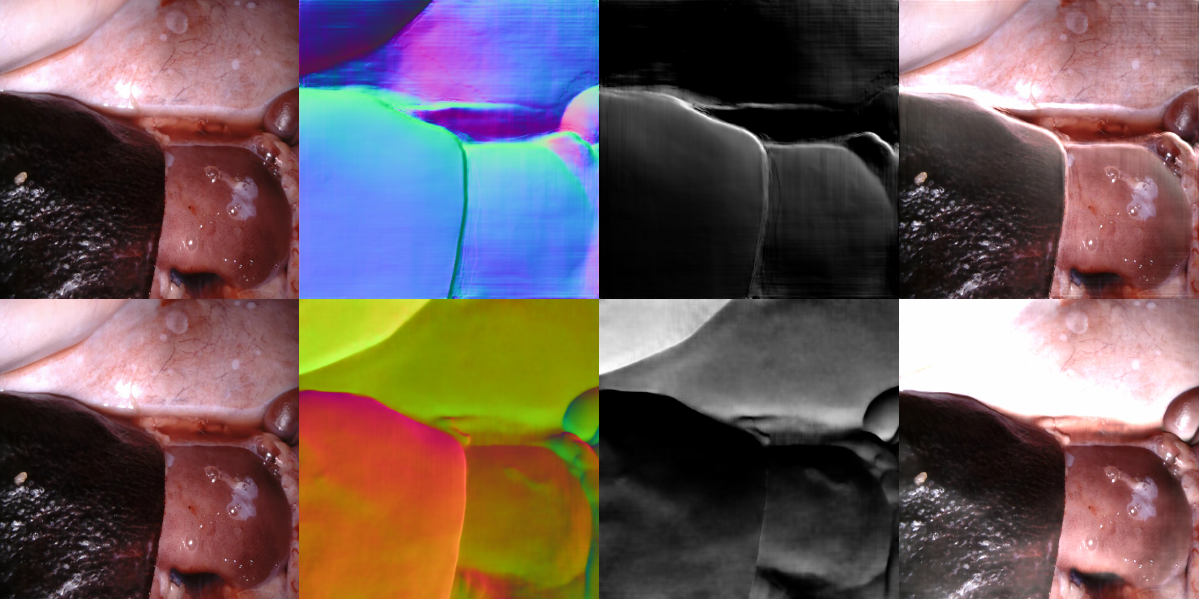

In [ ]:
# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()
# pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()


resultd = phd(
    rgb=image,
    intrinsic=intrinsic_res,
    shininess=2,
    ks=0.1,
)
result = ph(
    rgb=image,
    intrinsic=intrinsic_res,
    light_pos=resultd["light_pos"],
    shininess=2,
    ks=0.1,
)
rgb(
    panelize(
        panelize(
            rgb(
                image,
                resize=(300, 300),
                as_tensor=True,
            ),
            rgb(
                resultd["normals"][0],
                resize=(300, 300),
                as_tensor=True,
                colormap="rainbow",
            ),
            rgb(
                resultd["highlight"][0],
                resize=(300, 300),
                as_tensor=True,
                colormap="gray",
            ),
            rgb(resultd["rgb_highlighted"][0], resize=(300, 300), as_tensor=True),
        ),
        panelize(
            rgb(image, resize=(300, 300), as_tensor=True),
            rgb(
                result["normals"][0],
                resize=(300, 300),
                as_tensor=True,
                colormap="rainbow",
            ),
            rgb(
                result["highlight"][0],
                resize=(300, 300),
                as_tensor=True,
                colormap="gray",
            ),
            rgb(result["rgb_highlighted"][0], resize=(300, 300), as_tensor=True),
        ),
    mode="vertical",
    ),
)

In [8]:
resultd["normals"].shape

torch.Size([1, 3, 448, 448])

In [3]:
scared = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)
dataloader = torch.utils.data.DataLoader(scared, batch_size=1, shuffle=True)
idataloade = iter(dataloader)
for b, batch in enumerate(dataloader):
    break
print(batch.keys())


dict_keys(['rgb', 'specular', 'diffuse', 'intrinsics'])


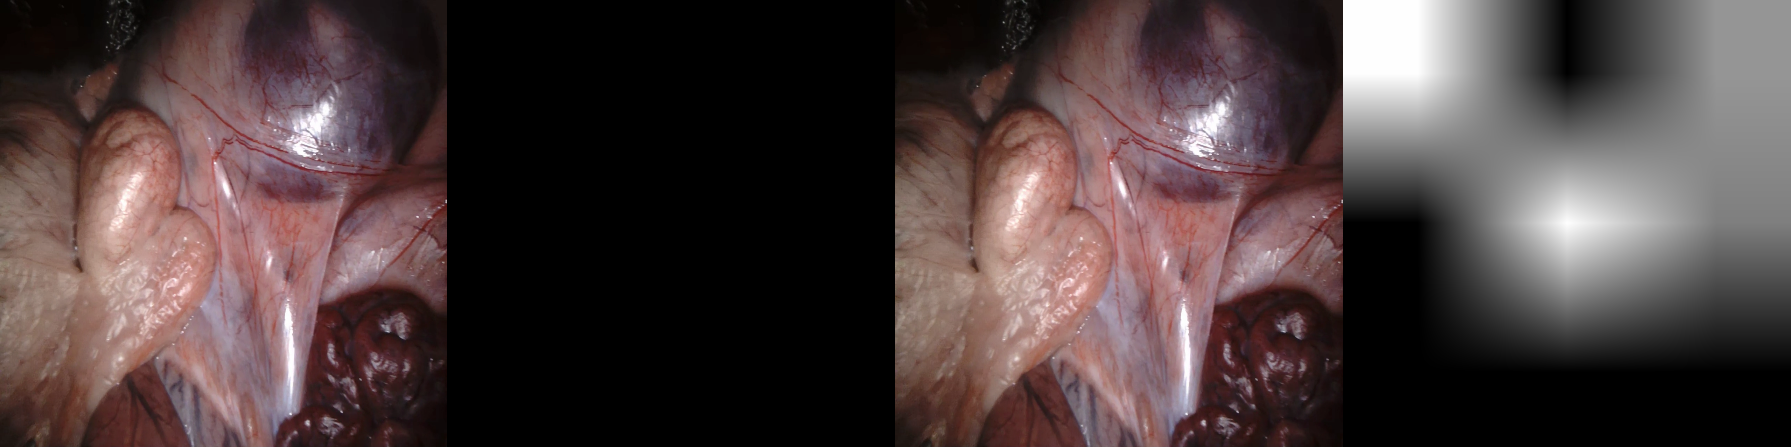

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["specular"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["diffuse"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
    )
)

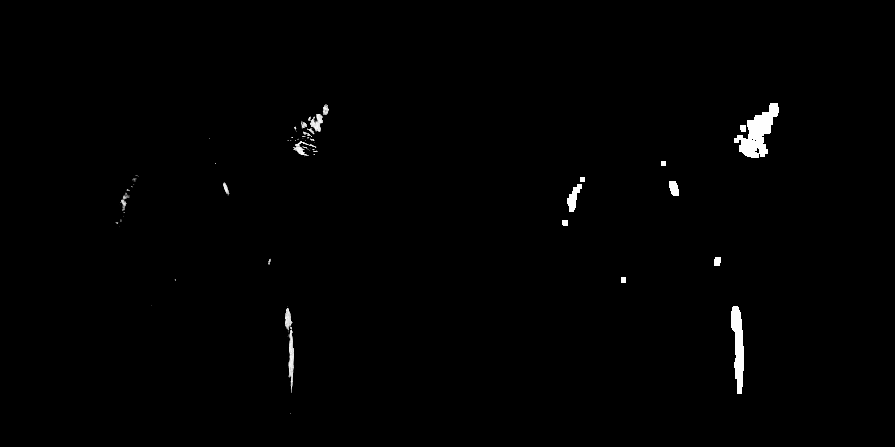

In [ ]:
real_highlight_soft_mask = get_soft_highlight_map(batch["rgb"].cuda(), 0.93)
inflated = (
    torch.nn.functional.max_pool2d(
        real_highlight_soft_mask, kernel_size=5, stride=1, padding=2
    )
    > 0.5
).int()
rgb(
    panelize(
        rgb(
            real_highlight_soft_mask, resize=(448, 448), colormap="gray", as_tensor=True
        ),
        rgb(inflated, resize=(448, 448), colormap="gray", as_tensor=True),
    )
)

In [ ]:
# from moge.model.v1 import MoGeModel
from moge.model.v2 import MoGeModel  # Let's try MoGe-2

MoGe = MoGeModel.from_pretrained("Ruicheng/moge-2-vits-normal")
with torch.no_grad():
    mogeout = MoGe.infer(image)  # Image is [Bx3xHxW]
depth = mogeout["depth"]  # [BxHxW]
normals = mogeout["normal"]  # [BxHxWx3]
# Infer
# output = MoGe.infer(input_image)
"""
`output` has keys "points", "depth", "mask", "normal" (optional) and "intrinsics",
The maps are in the same size as the input image. 
{
    "points": (H, W, 3),    # point map in OpenCV camera coordinate system (x right, y down, z forward). For MoGe-2, the point map is in metric scale.
    "depth": (H, W),        # depth map
    "normal": (H, W, 3)     # normal map in OpenCV camera coordinate system. (available for MoGe-2-normal)
    "mask": (H, W),         # a binary mask for valid pixels. 
    "intrinsics": (3, 3),   # normalized camera intrinsics
}
"""

In [12]:
batch["rgb"].shape

torch.Size([1, 3, 448, 448])

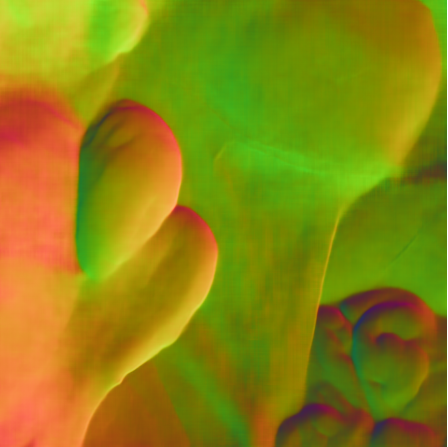

In [ ]:
rgb(mogeout["normal"][0], colormap="rainbow")

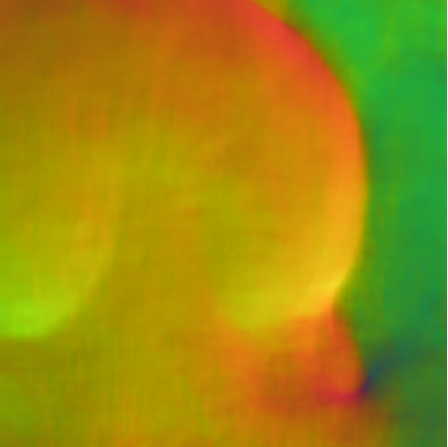

In [ ]:
from utilities import tensor_dict_summarize

tensor_dict_summarize(mogeout)


points: shape=(1, 448, 448, 3), device=cuda:0

intrinsics: shape=(1, 3, 3), device=cuda:0

depth: shape=(1, 448, 448), device=cuda:0

mask: shape=(1, 448, 448), device=cuda:0

normal: shape=(1, 448, 448, 3), device=cuda:0

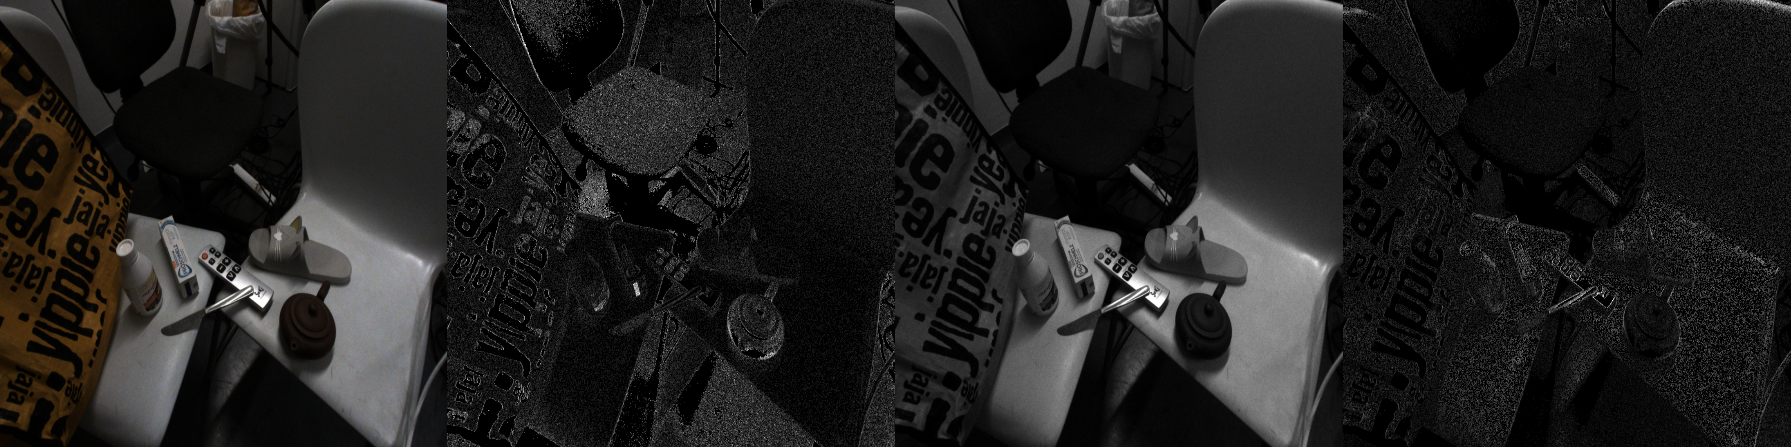

In [6]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/$DATASET_DIR/HouseCat6D/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["DoP"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["S0"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["f_spec"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
    )
)

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()

dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()


Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
rgb()

In [ ]:
dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()
# pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()


result = ph(
    rgb=image,
    intrinsic=intrinsic_res,
    shininess=100,
    ks=0.1,
)
rgb(
    panelize(
        rgb(image, resize=(448, 448), as_tensor=True),
        rgb(result["highlight"][0], resize=(448, 448), as_tensor=True, colormap="gray"),
        rgb(result["rgb_highlighted"][0], resize=(448, 448), as_tensor=True),
    )
)


In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
for i in range(400):
    rr.log(
        f"/light_{i}",
        rr.Points3D(
            positions=ph.sample_light_source(
                (-100, -10), (-110, 110), (-90, 90), batch_size=1
            )
            .cpu()
            .numpy()
            .reshape(1, 3),
            colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
            radii=0.5,
        ),
    )

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)

rr.notebook_show()


HTML(value='<div id="9b4be255-ec39-4c18-bc31-530f80e04799"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

Viewer()

In [21]:
for i in range(400):
    rr.log(
        f"/light_{i}",
        rr.Points3D(
            positions=ph.sample_light_source(
                (-300, -50), (-90, 90), (-180, -90), batch_size=1
            )
            .cpu()
            .numpy()
            .reshape(1, 3),
            colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
            radii=1,
        ),
    )

In [12]:
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
# for i in range(400):
rr.log(
    "/light",
    rr.Points3D(
        positions=result["light_pos"].cpu().numpy().reshape(1, 3),
        colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
        radii=5,
    ),
)

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)
# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 50
ARROW_LENGTH = 10
ARROW_RADIUS = 0.5
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::10, ::10].reshape(1, 3, -1)[0].permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS / 2,  # Arrow thickness
    ),
)
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(
            result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0])
        .expand_as(
            result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)

In [ ]:
for n, x in result.items():
    if x.ndim == 4 and n != "pcloud":
        print(n)
        rgb(x[0], resize=(448, 448))

In [ ]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/$DATASET_DIR/HouseCat6D/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()
pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()
intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892
result = ph(
    image,
    pol,
    intrinsic_res,
    shininess=80.0,
    ks=10.0,
)
# ph.print_timing_stats()
# rgb(
#     panelize(
#         *[
#             rgb(x[0], as_tensor=True, resize=(224, 224), title=n)
#             for n, x in result.items()
#             if x.ndim == 4 and n != "pcloud"
#         ],
#     )
# )
# image.shape, image.device, pol.shape, pol.device, intrinsic.shape, intrinsic.device
result = ph(
    image,
    pol,
    intrinsic_res,
    shininess=500.0,
    ks=20.0,
)
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
        rgb(
            result["rgb_highlighted"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
        rgb(
            result["highlight"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
    )
)

In [ ]:
# rgb(
#     panelize(
rgb(batch["DoP"], colormap="jet", resize=(448, 448))
(
    rgb(
        batch["AoP"][0],
        colormap="rainbow",
        resize=(448, 448),
    ),
)
#     )
# )

In [ ]:
# rgb(
#     panelize(
# rgb(image,  resize=(448, 448
(
    rgb(
        0.5 * result["H_dop"][0].cpu() + batch["DoP"][0].cpu(),
        colormap="jet",
        resize=(448, 448),
    ),
)
#     )
# )

In [ ]:
torch.cross(result["view_dir"], result["light_dir"], dim=1).shape

In [ ]:
k.shape

In [ ]:
# rgb(result["view_dir"][0], resize=(448, 448))
# rgb(result["light_dir"][0], resize=(448, 448))
k = torch.cross(result["view_dir"], result["light_dir"], dim=1).mean(dim=1)
# ex = k[:, 0:1]  # x-component [B,1,H,W]
# ey = k[:, 1:2]  # y-component [B,1,H,W]
# phi = torch.atan2(ey, ex)  # [-pi,pi] [B,1,H,W]
rgb(result["H_dop"], colormap="jet", resize=(448, 448))

In [ ]:
rgb(result["highlight"], colormap="gray", resize=(448, 448))

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=image.shape[2], width=image.shape[3]).cuda()
ph.enable_timing_mode(True)

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [ ]:
for n, x in result.items():
    if x.ndim == 4 and n != "pcloud":
        print(n)
        rgb(x[0], resize=(448, 448))

In [ ]:
result = ph(image, pol, intrinsic_res)
# ph.print_timing_stats()
rgb(
    panelize(
        *[
            rgb(x[0], as_tensor=True, resize=(448, 448), title=n)
            for n, x in result.items()
            if x.ndim == 4 and n != "pcloud"
        ],
    )
)

In [ ]:
rgb(
    panelize(
        rgb(image, as_tensor=True, resize=(448, 448), title="img"),
        rgb(
            result["rgb_highlighted"][0],
            as_tensor=True,
            resize=(448, 448),
            title="highlight",
        ),
    )
)

In [ ]:
result["normals"].shape

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [ ]:
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
# for i in range(400):
rr.log(
    "/light",
    rr.Points3D(
        positions=result["light_pos"].cpu().numpy().reshape(1, 3),
        colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
        radii=5,
    ),
)

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)
# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 50
ARROW_LENGTH = 10
ARROW_RADIUS = 0.5
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::10, ::10].reshape(1, 3, -1)[0].permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS / 2,  # Arrow thickness
    ),
)
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(
            result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0])
        .expand_as(
            result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)

In [ ]:
result["pcloud"].reshape(1, 3, -1)[0].permute(1, 0).shape

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
            panelize(
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            panelize(
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            mode="vertical",
        ),
        resize_to_match=False,
    )
)